This is AI Session #38 recording
File C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/lab2.csv 
An Aiminium smelting company needs to predict wheather its processing machines require servicing based on certain features.
Currently, they shut down operations every two months for inspections, which in inefficient.
They have collected data over sevaral years, including:
Temerature (in 0C),
Noise aplitude (in dB),
Vibration aplitude (in m/s2),
Visible wear, classificatied as "none", "moderate" or "major",
Inspection results.
where 1 means the machine needs servicing and 0 means no service is required.

What Needs to Be Done:
Develop a classificatier using the historical data to predict if a machine needs servicing (binary classifications 0 or 1).
Input features: Temparature, noise apmplitude, vibration aplitude, and visible wear.
Target: The inspection results (wheather servicing is needed or not).
Model Training: Train a machine learning model (logistics regression, decision tree, or Randomforest Tree)
using the provided features to predict if a service is requitred.

Objective: Use this classifier to reduce unnecessary shutdowns by predecting servicing needs
optimizing maintenance schedules and avoiding downtime.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score

In [2]:
# Data import and preprocessing
df = pd.read_csv('C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/lab2.csv')

print(df.head())

   Unnamed: 0  temperature      noise  vibration visible_wear  needs_servicing
0           0   141.049075  34.279563   2.424016        minor                1
1           1    62.196389  12.304506   3.378309        minor                1
2           2    73.786734   1.378659   2.059509     moderate                0
3           3    76.625404  29.617468  13.339712         none                1
4           4    59.204077  16.721451  10.234235        major                0


In [3]:
# Convert the "visible wear" data from categorical to numerical data in the range[0,1]
wear_mapping = {'none': 0, 'minor': 1/3, 'moderate': 2/3, 'major': 1}
df['visible_wear'] = df['visible_wear'].map(wear_mapping)

print(df['visible_wear'])

0       0.333333
1       0.333333
2       0.666667
3       0.000000
4       1.000000
          ...   
1232    1.000000
1233    0.666667
1234    0.666667
1235    0.333333
1236    0.000000
Name: visible_wear, Length: 1237, dtype: float64


In [4]:
df.head()

,Unnamed: 0,temperature,noise,vibration,visible_wear,needs_servicing
0,0,141.049075,34.279563,2.424016,0.333333,1
1,1,62.196389,12.304506,3.378309,0.333333,1
2,2,73.786734,1.378659,2.059509,0.666667,0
3,3,76.625404,29.617468,13.339712,0.000000,1
4,4,59.204077,16.721451,10.234235,1.000000,0


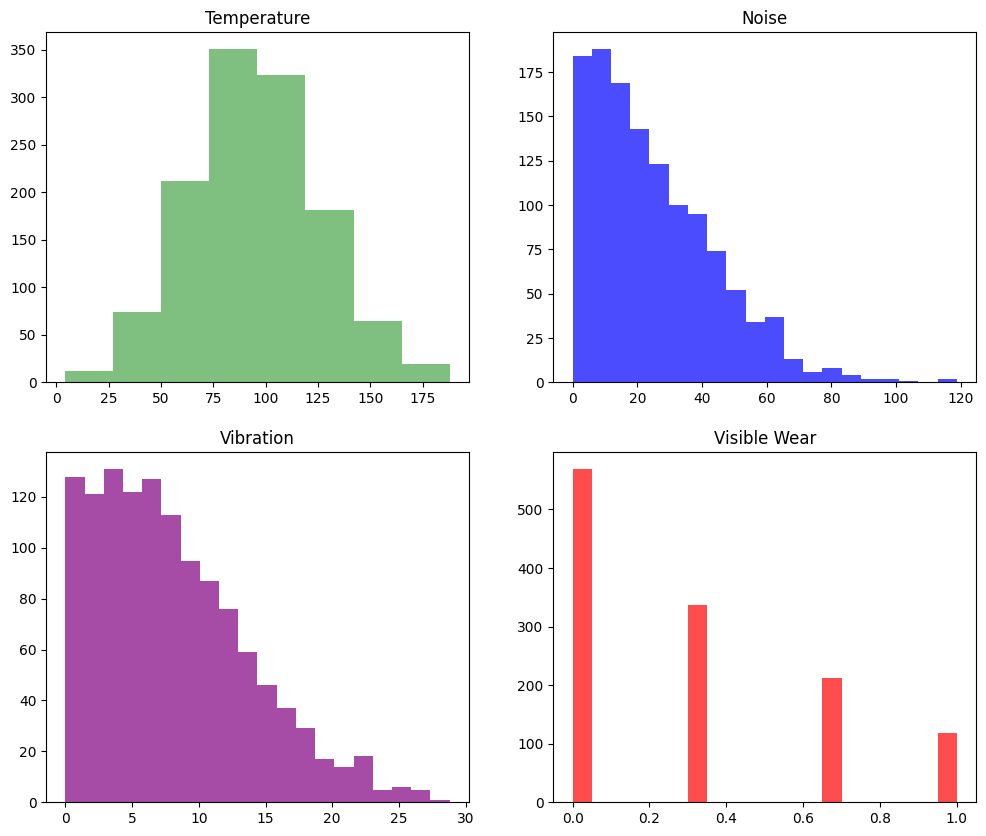

In [5]:
# Plot histograms of input data on four sub plots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
#alpha is transparency level of the bars it ranges between 0 to 1
axs[0, 0].hist(df['temperature'], bins=8, color='green', alpha=0.5)
axs[0, 0].set_title('Temperature')
axs[0, 1].hist(df['noise'], bins=20, color='blue', alpha=0.7)
axs[0, 1].set_title('Noise')
axs[1, 0].hist(df['vibration'], bins=20, color='purple', alpha=0.7)
axs[1, 0].set_title('Vibration')
axs[1, 1].hist(df['visible_wear'], bins=20, color='red', alpha=0.7)
axs[1, 1].set_title('Visible Wear')
plt.show()

In [6]:
# Split the data into training and testing sets
X = df[['temperature', 'noise', 'vibration', 'visible_wear']]
y = df['needs_servicing']  # this is the target column

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [8]:
print(X_train)#80 percent of data

      temperature      noise  vibration  visible_wear
365    129.777087  54.517646  14.560628      0.333333
526     78.386767  19.612294   2.186924      0.666667
430     67.196773  58.112959   2.889750      0.000000
350     64.249735  19.296426   6.141888      0.000000
566     74.912333   5.206710   4.746471      0.000000
...           ...        ...        ...           ...
1044   108.271318  15.844059   6.031025      0.333333
1095   119.346423  54.500619   0.902989      0.333333
1130   168.322472   1.047753  26.211902      0.000000
860     58.927561  54.262518   0.697304      0.333333
1126    49.179289  20.820950   7.305328      0.000000

[989 rows x 4 columns]


In [9]:
print(X_test)#20 percent of data

      temperature      noise  vibration  visible_wear
614    134.420985  27.215093  16.244294      0.000000
174    101.098926  28.439974   1.761677      0.000000
869    118.788345  25.472744   0.701117      0.000000
941     59.259438  11.701142  21.653464      0.000000
980    100.903068  12.475373   3.731184      0.666667
...           ...        ...        ...           ...
876     30.508796  68.291110   6.004661      0.333333
178     71.516494  28.569844  10.505736      0.000000
31     117.095806  53.595482   4.452760      0.666667
873     81.742356  34.483471   5.579250      0.000000
1004   139.272538  38.678152  13.599795      0.000000

[248 rows x 4 columns]


In [10]:
print(y_train)#80

365     0
526     1
430     1
350     1
566     1
       ..
1044    1
1095    1
1130    0
860     1
1126    1
Name: needs_servicing, Length: 989, dtype: int64


In [11]:
print(y_test)#20

614     0
174     1
869     1
941     0
980     1
       ..
876     0
178     1
31      0
873     1
1004    0
Name: needs_servicing, Length: 248, dtype: int64


In [ ]:
# Normalize the training data
scaler = MinMaxScaler()#Creating an object
X_train_normalized = scaler.fit_transform(X_train)
print(X_train_normalized)

[[0.70903668 0.45888072 0.50552664 0.33333333]
 [0.41879229 0.16502329 0.07564599 0.66666667]
 [0.35559298 0.48914855 0.10006319 0.        ]
 ...
 [0.92673492 0.00873413 0.91030897 0.        ]
 [0.30888978 0.45673287 0.0238944  0.33333333]
 [0.25383308 0.17519859 0.25346686 0.        ]]


In [13]:
# Apply the same normalization to the test set input data
X_test_normalized = scaler.transform(X_test)

In [14]:
#  Create input matrices
X_train = pd.DataFrame(X_train_normalized, columns=X.columns)
X_test = pd.DataFrame(X_test_normalized, columns=X.columns)

In [15]:
y_train

365     0
526     1
430     1
350     1
566     1
       ..
1044    1
1095    1
1130    0
860     1
1126    1
Name: needs_servicing, Length: 989, dtype: int64

In [16]:
# Output vectors y_train and y_test 
y_train = y_train.values 
y_test = y_test.values 

In [17]:
y_train

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,

In [34]:
y_test

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0])

In [ ]:
# Create logistic regression object
logisticRegr = LogisticRegression()#Reference variable creating a n Object

logistic regression is classifcation algorithm.

we can use when output is categorical

mostly forr binary classification---0 or 1

here we use the linear regression -->y=wx+b

we can convert this output into probability using Sigmoid function.

1/1+e power -z

here z=wx+b

here the output is 0 to 1 only

z=w1x1+w2x2+.....+b

then

y=sigmoid(z)-->it gives probability value-->0 to 1-->0.4?

here we take decsion boundary,

if P>=0.5-->class 1 if P<0.5 -->class 0

Cost function:
wE dont use MSE,MAE...

we have Log loss-->Binary cross entropy-->1/n summation ylog(y_pred)+((1-y)log(1-y_pred))

In [19]:
# Fit the model to the training data
logisticRegr.fit(X_train, y_train)#here the algorithm lerns the patterns from the data
#take my x and y values learn something that is how they relate

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
# Predict the outputs of the test set
y_pred = logisticRegr.predict(X_test)

In [21]:
print("y_pred are",y_pred)#predicted data

y_pred are [0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 0 0 1 1 1
 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0
 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0
 1 1 0 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 1 1 1
 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 0 1 1 1 1 0 1 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0
 1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0]


In [22]:
y_test#actual data

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0])

In [23]:
# Use the score method to calculate the accuracy on the test set
#evaluating the model
accuracy = logisticRegr.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 86.29%


In [24]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)#It is a two dimensional matrix

[[111  19]
 [ 15 103]]


Confusion matrix is a table that evaluates the performance of a classification model by comparing predicted versus actual target values. | Predicted Positive ->1 | Predicted Negative-0

Actual Positive -1 | TP | FN
Actual Negative -0 | FP | TN

TP-->True positive-->Correctly predicted positive

TN-->True Negative-->Correclty predicted negative

FP-->False Positives-->Incorrectly predicted positive

FN-->False Negative-->Incorrectly predicted negative

In [26]:
tn, fp, fn, tp = conf_matrix.ravel()
print(f"Confusion Matrix:\nTrue negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True positives: {tp}")

Confusion Matrix:
True negatives: 111, False Positives: 19, False Negatives: 15, True positives: 103


In [29]:
pre=precision_score(y_test,y_pred)

In [30]:
pre

0.8442622950819673

In [31]:
rec=recall_score(y_test,y_pred)

In [32]:
f1=f1_score(y_test,y_pred)

In [33]:
print("Precsion is ",pre)
print("recall is ",rec)
print("f1 is ",f1)

Precsion is  0.8442622950819673
recall is  0.8728813559322034
f1 is  0.8583333333333333


This is end of AI Session # 38